In [1]:
# Hierarchical clustering is suitable because:
# We do not know the number of visitor groups in advance.
# It creates a dendrogram (tree structure) that visually shows grouping.
# It works well for small to medium datasets.
# Helps understand natural grouping patterns in visitor behavior.
# Since this is behavior segmentation → unsupervised clustering is appropriate.

In [2]:
# Using Visit_Frequency Avg_Time_Spent Avg_Spend

In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

In [4]:
df = pd.read_csv("mall_visitors.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (15, 4)
   VisitorID  Visit_Frequency  Avg_Time_Spent  Avg_Spend
0          1                2              30        500
1          2                5              45       1500
2          3                1              20        300
3          4                8              60       3000
4          5                3              35        800


In [5]:
X = df.drop("VisitorID", axis=1)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

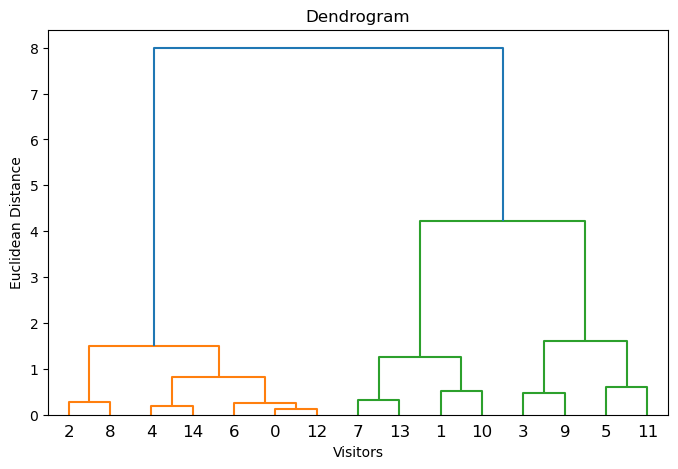

In [6]:
plt.figure(figsize=(8,5))
dendrogram = sch.dendrogram(
    sch.linkage(X_scaled, method='ward')
)
plt.title("Dendrogram")
plt.xlabel("Visitors")
plt.ylabel("Euclidean Distance")
plt.show()

In [8]:
# ============================
# Apply Agglomerative Clustering
# Assume optimal clusters = 3 (based on dendrogram)
# ============================

model = AgglomerativeClustering(n_clusters=3, linkage='ward')
df["Cluster"] = model.fit_predict(X_scaled)
print("\nVisitors per Cluster:")
print(df["Cluster"].value_counts())


Visitors per Cluster:
Cluster
1    7
2    4
0    4
Name: count, dtype: int64


In [9]:
cluster_summary = df.groupby("Cluster").mean()
print("\nCluster Summary:")
print(cluster_summary)


Cluster Summary:
         VisitorID  Visit_Frequency  Avg_Time_Spent    Avg_Spend
Cluster                                                         
0         8.000000             8.50       67.500000  3325.000000
1         7.571429             2.00       26.428571   478.571429
2         8.750000             5.25       47.500000  1625.000000
